# FlexBE with a microcoded command processor

**Companion notebook to** X. Liu, R. Wu, P. H. W. Leong, *"A Flexible FPGA-based
Butterfly Engine for Accelerating Signal Processing and Machine Learning"*.

Two things are established here.

1. **A cycle-level model of the engine**, which reproduces the paper's headline
   numbers exactly — 15,360 cycles for four 32,768-point FFTs, 0.214 ms for
   cfg-6 at 300 MHz — and which turned up an error in Algorithm 1 along the way.
   The repaired index generator is derived, proved and used as the *only*
   control path in the simulator.

2. **A microcoded command processor** that makes the accelerator programmable:
   a PL-side sequencer executing 32-byte descriptors. It costs **~3.6k LUT
   (+2.4%)** and lands within **9% of the hardwired datapath**, and it shows
   that the PYNQ flow the paper measures is *host bound*, not accelerator bound.

Nothing is asserted where it could be measured. The simulator executes the real
dataflow — banked RAM, switching network, butterfly units, per-cycle control —
and every architectural claim below is checked by the accompanying test suite.
Assumptions are confined to one dataclass, `MicrocodeConfig`, and listed in
Part IV.

---
## 0. Setup

| module | contents |
|---|---|
| `flexbe.py` | the engine: shift-down memory, PRS, Algorithm 1, bit reversal, arithmetic, Eq. (10) |
| `bspnet.py` | the application: Eq. (1) features, BL branches, Table 7 configs |
| `microcode.py` | descriptors, program builder, sequencer, Zynq attachment |
| `test_flexbe.py` | 50 tests |

In [1]:
import math, sys, subprocess
import numpy as np
import matplotlib.pyplot as plt

import flexbe as fx
import bspnet as bs
import microcode as mc

plt.rcParams.update({"figure.figsize": (7.2, 3.6), "figure.dpi": 110,
                     "axes.grid": True, "grid.alpha": 0.3, "font.size": 9})
print("numpy", np.__version__, "| python", sys.version.split()[0])

numpy 2.4.6 | python 3.13.13


---
# Part I — The engine

## 1.1 Shift-down storage, Eq. (3)

Data in flight lives in $P = 2P_{bu}$ single-port banks. Element $I$ sits in bank
$a_y$ at depth $a_x$:

$$a_x = I \gg m, \qquad a_y = \mathrm{bsm}(I) = \big[\mathrm{popcount}(I \gg m) + (I \bmod 2^m)\big] \bmod 2^m$$

The useful way to read this — and worth stating explicitly in the paper, because
it makes every later argument a one-liner:

> **A RAM row is $2^m$ consecutive indices, and row $H$ is stored cyclically
> rotated by $\mathrm{popcount}(H)$ banks.**

Two consequences follow immediately: the map is a bijection, and the $2^m$
elements of one row occupy **all** $2^m$ banks exactly once.

In [2]:
m, n = 3, 6                      # P_bu = 4 -> 8 banks, N = 64
N, P = 1 << n, 1 << m
idx = np.arange(N)
slots = fx.bsm_array(idx, m) * (N // P) + (idx >> m)
print("bijection:", len(np.unique(slots)) == N)
print("\nbanks of the first four rows:")
for H in range(4):
    row = idx[(idx >> m) == H]
    print(f"  H={H}  popcount={fx.popcount(H)}  banks={fx.bsm_array(row, m).tolist()}")

bijection: True

banks of the first four rows:
  H=0  popcount=0  banks=[0, 1, 2, 3, 4, 5, 6, 7]
  H=1  popcount=1  banks=[1, 2, 3, 4, 5, 6, 7, 0]
  H=2  popcount=1  banks=[1, 2, 3, 4, 5, 6, 7, 0]
  H=3  popcount=2  banks=[2, 3, 4, 5, 6, 7, 0, 1]


## 1.2 The schedule, and why $h = n-1-k$

Stage $k$ pairs indices differing in bit $h$. The paper's control law (Algorithm 1
line 9, $S^i = n-k-1$ on $(n-m)\le k\le(n-2)$) is only correct for

$$h = n-1-k$$

i.e. decimation in frequency: natural-order input, bit-reversed output — which is
precisely what the Sec. 3.3 write-back exists to undo. Given that, conflict
freedom forces two regimes:

**$h < m$** — both operands share a row. Read the whole row: banks
$(\mathrm{popcount}(H)+\mathit{low})\bmod 2^m$ are all distinct, and slot $j$ reads bank
$(\pi_h[j]+\mathrm{popcount}(H))\bmod 2^m$ — a fixed stride permutation then a
rotation, so $\mathbf{P}_f = \mathbf{P}_s\times\mathbf{P}_r$ with $S=h$.

**$h \ge m$** — the partner is in row $H+2^{h-m}$. Pick $H$ with bit $h{-}m$ clear,
so $\mathrm{popcount}(H+2^{h-m}) = \mathrm{popcount}(H)+1$; take the $P_{bu}$ even (or odd)
low values from both rows and slot $j$ reads bank
$(\mathrm{popcount}(H)+e+j)\bmod 2^m$ — a pure rotation, $S=0$.

**The subset-switch state falls out as $S = h$ when $h<m$, else 0 — identical to
the published line 9.**

In [3]:
sched = fx.ButterflySchedule(n=10, P_bu=16, validate=True)
print(f"N={sched.N}, 2*P_bu={sched.P}, stages={sched.n_stages}, "
      f"cycles/stage={sched.cycles_per_stage}, total={sched.total_cycles}")
print("validate(): conflict-free, complete, PRS == FCS, R = bsm(I[0]), "
      "S == published law\n")
print(f"{'k':>2} {'hole h':>7} {'S':>3} {'published S':>12} {'regime':>8} {'R of first 4 cycles':>22}")
for k, stage in enumerate(sched.stages):
    c = stage[0]
    print(f"{k:>2} {c.hole:>7} {c.S:>3} {sched.published_subset_state(k):>12} "
          f"{('row' if c.hole < sched.m else '2-row'):>8} "
          f"{', '.join(str(x.R) for x in stage[:4]):>22}")

N=1024, 2*P_bu=32, stages=10, cycles/stage=32, total=320
validate(): conflict-free, complete, PRS == FCS, R = bsm(I[0]), S == published law

 k  hole h   S  published S   regime    R of first 4 cycles
 0       9   0            0    2-row             0, 1, 1, 2
 1       8   0            0    2-row             0, 1, 1, 2
 2       7   0            0    2-row             0, 1, 1, 2
 3       6   0            0    2-row             0, 1, 1, 2
 4       5   0            0    2-row             0, 1, 1, 2
 5       4   4            4      row             0, 1, 1, 2
 6       3   3            3      row             0, 1, 1, 2
 7       2   2            2      row             0, 1, 1, 2
 8       1   1            1      row             0, 1, 1, 2
 9       0   0            0      row             0, 1, 1, 2


## 1.3 PRS versus FCS

The FCS is a general crossbar: $2P_{bu}$ ports, each a $2P_{bu}$-to-1 mux, i.e.
$2P_{bu}-1$ 2:1 muxes each (Eq. 4) — $\Theta(P_{bu}^2)$. The PRS is a barrel
shifter plus one of only $m$ stride permutations — $\Theta(mP_{bu})$.

**By hand at 128 ports** ($P_{bu}=64$, $m=7$): $128\times127 = 16{,}256$ against
$7(128)+8(64) = 1{,}408$, a factor of 11.5. Note the crossover — at 4 ports the
staged PRS is *worse* (14 vs 12), consistent with Fig. 9 starting where the
curves nearly touch.

 ports  m   FCS mux2   PRS mux2   ratio
     4  2         12         14   0.86x
     8  3         56         40   1.40x
    16  4        240        104   2.31x
    32  5        992        256   3.88x
    64  6      4,032        608   6.63x
   128  7     16,256      1,408  11.55x


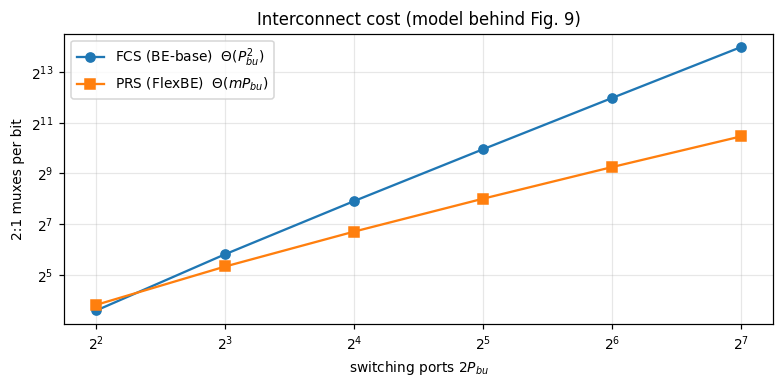

In [4]:
ports, fcs, prs = [], [], []
print(f"{'ports':>6} {'m':>2} {'FCS mux2':>10} {'PRS mux2':>10} {'ratio':>7}")
for P_bu in (2,4,8,16,32,64):
    c = fx.interconnect_cost(P_bu)
    ports.append(c['ports']); fcs.append(c['fcs_mux2']); prs.append(c['prs_mux2'])
    print(f"{c['ports']:>6} {c['m']:>2} {c['fcs_mux2']:>10,} {c['prs_mux2']:>10,} {c['ratio']:>6.2f}x")

fig, ax = plt.subplots()
ax.plot(ports, fcs, 'o-', label='FCS (BE-base)  $\\Theta(P_{bu}^2)$')
ax.plot(ports, prs, 's-', label='PRS (FlexBE)  $\\Theta(m P_{bu})$')
ax.set_xscale('log', base=2); ax.set_yscale('log', base=2)
ax.set_xlabel('switching ports $2P_{bu}$'); ax.set_ylabel('2:1 muxes per bit')
ax.set_title('Interconnect cost (model behind Fig. 9)'); ax.legend()
plt.tight_layout(); plt.show()

## 1.4 One datapath, two workloads

A butterfly unit applies a general $2\times2$ coefficient matrix. The FFT is the
special case $\begin{pmatrix}1&1\\W&-W\end{pmatrix}$; a BL layer uses trained
weights — exactly the `[2,2,l/2,log2 l]` shape of Table 4.

In [5]:
eng = fx.FlexBE(P_bu=16)
rng = np.random.default_rng(0)

x = rng.normal(size=(4,1024)) + 1j*rng.normal(size=(4,1024))
y, st = eng.transform(x, bitrev=True, datapath='cycle')
ref = np.fft.fft(x, axis=1)
print("FFT :", st)
print("      max relative error vs numpy.fft =",
      f"{np.max(np.abs(y-ref))/np.max(np.abs(ref)):.2e}")

W = fx.random_bl_coefficients(32, rng)
M = np.asarray(eng.transform(np.eye(32), W, datapath='cycle')[0]).T
z = rng.normal(size=(7,32))
yb, _ = eng.transform(z, W, datapath='cycle')
print("\nBL  : engine output equals the dense butterfly matrix:", np.allclose(yb, z @ M.T))

FFT : N=1024 l=1024 P_sub=1 P_N=4 stages=10 bfly=1280 bitrev=128 total=1408
      max relative error vs numpy.fft = 4.58e-16

BL  : engine output equals the dense butterfly matrix: True


## 1.5 Sub-parallelism (Alg. 2, Eq. 5) and bit reversal (Alg. 3)

BE-base cannot process $l < 2P_{bu}$ — short vectors must be zero padded.
FlexBE interleaves $P_{sub} = 2P_{bu}/l$ transforms into one vector and stops
after $\log_2 l$ stages. This is where BSPNet spends its time: cfg-6 has
$d_{in}=8$ against $2P_{bu}=32$, so $P_{sub}=4$.

**By hand** — 1024 vectors of length 8 on one $P_{bu}=16$ engine: padding costs
$1024\times 32/32\times 5 = 5{,}120$ cycles, sub-parallelism costs
$1024/4\times 3 = 768$. Ratio $6.67\times$ = $P_{sub}$ (4) times the wasted
stages ($5/3$).

Algorithm 3 then writes back through the bit-reversal network in exactly $N/P$
cycles, conflict free on *both* memories, with lane $a$ always reading bank $a$
and destination bank $\mathrm{bit\text{-}rev}_m((a+u)\bmod P)$ (Eq. 7). That part of
the paper is correct as printed.

In [6]:
print(f"{'l':>4} {'N':>5} {'P_sub':>6} {'cycles/1024 vec':>16} {'vs zero-pad':>12}")
for l in (2,4,8,16,32,64):
    N_, ps = eng.geometry(l)
    flex = fx.layer_cycles(1024, l, P_be=1, P_bu=16)
    pad  = fx.layer_cycles(1024, max(l,32), P_be=1, P_bu=16)
    print(f"{l:>4} {N_:>5} {ps:>6} {flex:>16,.0f} {pad/flex:>11.2f}x")

print(f"\n{'N':>7} {'P':>4} {'cycles':>8} {'N/P':>6}  read-CF  write-CF  lane a -> bank a  permutation")
for N_, P_bu in [(1024,16),(32768,16),(4096,4)]:
    nn, mm = int(math.log2(N_)), (2*P_bu).bit_length()-1
    j, k = fx.bitrev_schedule(nn, mm); Pp = 1 << mm
    print(f"{N_:>7} {Pp:>4} {j.shape[0]:>8} {N_//Pp:>6}  "
          f"{str(all(len(np.unique(fx.bsm_array(jv,mm)))==Pp for jv in j)):>7}  "
          f"{str(all(len(np.unique(kv & (Pp-1)))==Pp for kv in k)):>8}  "
          f"{str(all(np.array_equal(fx.bsm_array(jv,mm), np.arange(Pp)) for jv in j)):>16}  "
          f"{len(np.unique(j))==N_ and np.array_equal(k, fx.bit_rev_array(nn)[j])}")

   l     N  P_sub  cycles/1024 vec  vs zero-pad
   2    32     16               64       80.00x
   4    32      8              256       20.00x
   8    32      4              768        6.67x
  16    32      2            2,048        2.50x
  32    32      1            5,120        1.00x
  64    64      1           12,288        1.00x

      N    P   cycles    N/P  read-CF  write-CF  lane a -> bank a  permutation
   1024   32       32     32     True      True              True  True
  32768   32     1024   1024     True      True              True  True
   4096    8      512    512     True      True              True  True


## 1.6 Eq. (10) and the abstract's headline

$$\text{cycles} \approx \frac{P_N N}{2P_{sub}P_{be}P_{bu}}\times\log_2\frac{N}{P_{sub}}$$

**By hand**, four 32,768-point FFTs on $P_{be}=4$, $P_{bu}=16$:

$$\frac{4\times 32768}{2\times1\times4\times16}\times 15 = 1024\times 15 = 15{,}360 \text{ cycles} = 51.2\,\mu s \text{ at } 300\,\text{MHz}$$

One clarification worth adding to the paper: $P_N$ must be read as the number of
length-$l$ *input* sequences and $N$ as the engine computational length
$\max(l, 2P_{bu})$; with that reading the expression is consistent for all
$P_{sub}$.

In [7]:
print("Eq. (10):", f"{fx.cycles_eq10(4, 32768, 1, P_be=4, P_bu=16):,.0f} cycles  (paper: 15,360)")
arr = fx.BEArray(P_be=4, P_bu=16)
xb = rng.normal(size=(4,32768)) + 1j*rng.normal(size=(4,32768))
yb, stb = arr.transform(xb, bitrev=True, datapath='cycle')
print("measured:", f"{stb.butterfly_cycles:,} butterfly + {stb.bitrev_cycles:,} bit-reversal cycles")
print("          max abs error vs numpy.fft =", f"{np.max(np.abs(yb-np.fft.fft(xb,axis=1))):.2e}")

fmt = fx.FixedPointFormat()
xq = fmt.quantise((rng.normal(size=1024)+1j*rng.normal(size=1024))/8)
yq, stq = fx.FlexBE(16, fmt=fmt).transform(xq, bitrev=True, stage_scale=0.5, datapath='cycle')
e = np.linalg.norm(yq[0]-np.fft.fft(xq)*stq.scale)/np.linalg.norm(np.fft.fft(xq)*stq.scale)
print(f"\nfxp16 Q1.15, 1/2 per stage, N=1024: NRMSE {e:.2e} -> SQNR {20*math.log10(1/e):.1f} dB")

Eq. (10): 15,360 cycles  (paper: 15,360)
measured: 15,360 butterfly + 1,024 bit-reversal cycles
          max abs error vs numpy.fft = 6.92e-13

fxp16 Q1.15, 1/2 per stage, N=1024: NRMSE 3.73e-03 -> SQNR 48.6 dB


## 1.7 BSPNet

In [8]:
print(bs.design_space_table())
cfg, hw = bs.CONFIGS['cfg-6'], bs.HW['BSP-Flex']
print(f"\ncfg-6 on BSP-Flex ({hw.f_mhz:.0f} MHz, P_be={hw.P_be}, P_bu={hw.P_bu}):")
tot = 0
for name, cyc in bs.cycle_breakdown(cfg, hw):
    tot += cyc
    print(f"  {name:44s} {cyc:10,.0f} cyc  {cyc/300e6*1e3:7.4f} ms")
print(f"  {'total':44s} {tot:10,.0f} cyc  {tot/300e6*1e3:7.4f} ms"
      f"   ->  {1e3/(tot/300e6*1e3):,.0f} samples/s")

config    d_in  d_m     L  blk  brev |    BE-base-1 cyc      ms |    BE-base-2 cyc      ms |       FlexBE cyc      ms
---------------------------------------------------------------------------------------------------------------------
cfg-1        8   64   512    3  True |           93,568   0.446 |          372,096   3.236 |           93,568   0.302
cfg-2        8   64   512    2  True |           93,184   0.444 |          371,712   3.232 |           93,184   0.301
cfg-3        4   32  1024    3  True |          138,048   0.657 |          695,104   6.044 |           72,512   0.234
cfg-4        4   32  1024    3 False |          137,024   0.652 |          694,080   6.035 |           71,488   0.231
cfg-5        8   32   512    3  True |           52,640   0.251 |          191,904   1.669 |           52,640   0.170
cfg-6        8   32  1024    3  True |           64,320   0.306 |          203,584   1.770 |           64,320   0.207
cfg-7       16   32  1024    3  True |           56,128 

---
# Part II — An error in Algorithm 1

## 2.1 The two halves

| lines | content | status |
|---|---|---|
| 5–6 | $ii \leftarrow \mathrm{rotate}_{n-1}(base,k{+}1)$; $I^i[0]\leftarrow\mathrm{rotate}_n(2ii,k)$ | **does not give a conflict-free grouping** |
| 7–11 | $R^i = \mathrm{bsm}(I^i[0])$; $S^i = n{-}k{-}1$ on $(n{-}m)..(n{-}2)$, else 0 | correct — keep verbatim |

Since $\mathrm{rotate}_n(2x,k) = \mathrm{ins}(\mathrm{rotate}_{n-1}(x,k),k)$,

$$I^i[0] = \mathrm{ins}\big(\mathrm{rotate}_{n-1}(base,\,2k+1),\;k\big)$$

— the operand is rotated **twice** by roughly the stage index, and the hole lands
at bit $k$ instead of $n-1-k$. Only $h = n-1-k$ is compatible with line 9 and
with the Sec. 3.3 write-back.

In [9]:
def published(n, P_bu, k, j, rot=1):
    "Algorithm 1 lines 5-6 exactly as printed (rot=1)."
    return fx.rotl(2*fx.rotl(j*P_bu, k+rot, n-1), k, n) if hasattr(fx,'rotl') else None

def rotl(x, q, width):
    q %= width; mask = (1<<width)-1; x &= mask
    return x if q == 0 else ((x << q) | (x >> (width-q))) & mask

def published(n, P_bu, k, j, rot=1):
    return rotl(2*rotl(j*P_bu, k+rot, n-1), k, n)

n_, P_bu = 10, 16
ok = all(published(n_,P_bu,k,j) == fx.insert_zero(rotl(j*P_bu, 2*k+1, n_-1), k)
         for k in range(n_) for j in range(1 << (n_-5)))
print("rotate_n(2*ii,k) == ins(rotate_{n-1}(base,2k+1), k):", ok)

rotate_n(2*ii,k) == ins(rotate_{n-1}(base,2k+1), k): True


## 2.2 Exhaustive counterexample

For small cases we enumerate **every** conflict-free grouping of a stage and ask
whether any admits the published $I^i[0]$ values as distinct cycle
representatives. For $N=8$, $P_{bu}=2$ the only conflict-free grouping is the
row-based $\{0,1,2,3\}/\{4,5,6,7\}$, while the formula yields representatives
$0$ and $2$ — which share a row. That is a proof, not a symptom. Both rotation
readings and both stage orders are tried.

In [10]:
import itertools
def matchings(items, size):
    if not items: yield []; return
    first, rest = items[0], items[1:]
    for comb in itertools.combinations(rest, size-1):
        remain = [x for x in rest if x not in comb]
        for tail in matchings(remain, size): yield [(first,)+comb] + tail

rules = {'DIF  h=n-1-k': lambda n,k: n-1-k, 'DIT  h=k    ': lambda n,k: k}
for nn, P_bu in [(3,2),(4,2),(5,2)]:
    mm = (2*P_bu).bit_length()-1; N_, Pp = 1<<nn, 1<<mm
    for label, rule in rules.items():
        for rot in (1,0):
            verdict = "feasible"
            for k in range(nn):
                h = rule(nn,k)
                lower = [a for a in range(N_) if not (a>>h)&1]
                parts = [g for g in matchings(lower, P_bu)
                         if all(len({fx.bsm(x,mm) for a in grp for x in (a,a+(1<<h))})==Pp
                                for grp in g)]
                reps = [published(nn,P_bu,k,j,rot) for j in range(N_//Pp)]
                def cyc_of(part, r):
                    return next(i for i,grp in enumerate(part)
                                if any(r in (a,a+(1<<h)) for a in grp))
                if not any(len({cyc_of(p,r) for r in reps})==len(reps) for p in parts):
                    verdict = (f"INFEASIBLE at k={k} (h={h}): none of {len(parts)} "
                               f"conflict-free partitions admits reps={reps}")
                    break
            print(f"N={N_:>3} P_bu={P_bu} {label} rot=k+{rot}: {verdict}")

N=  8 P_bu=2 DIF  h=n-1-k rot=k+1: INFEASIBLE at k=0 (h=2): none of 1 conflict-free partitions admits reps=[0, 2]
N=  8 P_bu=2 DIF  h=n-1-k rot=k+0: INFEASIBLE at k=0 (h=2): none of 1 conflict-free partitions admits reps=[0, 4]
N=  8 P_bu=2 DIT  h=k     rot=k+1: INFEASIBLE at k=0 (h=0): none of 1 conflict-free partitions admits reps=[0, 2]
N=  8 P_bu=2 DIT  h=k     rot=k+0: INFEASIBLE at k=2 (h=2): none of 1 conflict-free partitions admits reps=[0, 2]
N= 16 P_bu=2 DIF  h=n-1-k rot=k+1: INFEASIBLE at k=0 (h=3): none of 4 conflict-free partitions admits reps=[0, 8, 2, 10]
N= 16 P_bu=2 DIF  h=n-1-k rot=k+0: INFEASIBLE at k=0 (h=3): none of 4 conflict-free partitions admits reps=[0, 4, 8, 12]
N= 16 P_bu=2 DIT  h=k     rot=k+1: feasible
N= 16 P_bu=2 DIT  h=k     rot=k+0: feasible
N= 32 P_bu=2 DIF  h=n-1-k rot=k+1: INFEASIBLE at k=0 (h=4): none of 576 conflict-free partitions admits reps=[0, 8, 16, 24, 2, 10, 18, 26]
N= 32 P_bu=2 DIF  h=n-1-k rot=k+0: INFEASIBLE at k=0 (h=4): none of 576 con

## 2.3 The repair

Only lines 5–6 change. With $\mathrm{ins}(x,p) = ((x \gg p)\ll(p{+}1))\,|\,(x \bmod 2^p)$:

```
h <- n-1-k
if h < m:  H <- j                      I^i[2t] <- (H << m) + ins(t, h)     S^i <- h
else:      e <- j mod 2
           H <- ins(j >> 1, h-m)       I^i[2t] <- (H << m) + 2t + e        S^i <- 0
both:      I^i[2t+1] <- I^i[2t] + 2^h  R^i <- bsm(I^i[0])
```

* $S^i = h$ for $h<m$ **is** the published $S^i = n-k-1$ — line 9 survives untouched;
* $R^i$ reads off the construction as $\mathrm{popcount}(H)+e$, cheaper than recomputing bsm;
* the revised listing gives the **whole** vector $I^i[0..2P_{bu}{-}1]$, which the published version delegates to "a specific circuit" of [11] — the gap a reimplementer falls into.

Conflict freedom is the two-case argument of §1.2. Hardware cost is unchanged in
character: an $(n{-}m)$-bit counter, one insert-a-zero network at a
stage-constant position (one 2:1 mux per bit, select = thermometer code of
$h{-}m$, folding into the existing barrel-shifter control), and a popcount the
bsm datapath already computes — still far lighter than BE-base's
priority-encoder reverse lookup, so Fig. 10 is unaffected.

`flexbe.algorithm1()` is a direct transcription and is the **only** control path
in this simulator: every FFT and BL result above was produced by it.
`docs/algorithm1_fix.md` has the full argument, `docs/algorithm1_fixed.tex` a
drop-in `algorithm2e` listing.

In [11]:
print(f"{'N':>7} {'P_bu':>5}  conflict-free  complete  pairing  lines 7-11")
for nn, P_bu in [(3,1),(4,2),(6,2),(6,4),(9,4),(10,16),(12,16)]:
    mm = (2*P_bu).bit_length()-1
    if nn < mm: continue
    N_, Pp = 1<<nn, 1<<mm
    cf = comp = pair = law = True
    for k in range(nn):
        h, seen = nn-1-k, np.zeros(N_, bool)
        wantS = (nn-k-1) if (nn-mm) <= k <= (nn-2) else 0
        for j in range(N_//Pp):
            c = fx.algorithm1(nn, P_bu, k, j)
            cf   &= len(np.unique(fx.bsm_array(c.indices, mm))) == Pp
            comp &= not seen[c.indices].any(); seen[c.indices] = True
            pair &= bool(np.all(c.indices[1::2]-c.indices[0::2] == (1<<h)))
            law  &= (c.R == fx.bsm(int(c.indices[0]), mm)) and (c.S == wantS)
        comp &= seen.all()
    print(f"{N_:>7} {P_bu:>5}  {str(cf):>13}  {str(comp):>8}  {str(pair):>7}  {law}")

      N  P_bu  conflict-free  complete  pairing  lines 7-11
      8     1           True      True     True  True
     16     2           True      True     True  True
     64     2           True      True     True  True
     64     4           True      True     True  True
    512     4           True      True     True  True
   1024    16           True      True     True  True
   4096    16           True      True     True  True


---
# Part III — The microcoded command processor

## 3.1 Why a sequencer

FlexBE as published is fixed function: the layer sequence is hardwired. The
minimal change that makes it programmable is a PL-side sequencer executing a
queue of descriptors.

On Zynq this is also the *only* option: the Cortex-A53 is hard IP, so there is
no custom-instruction port (Arm Custom Instructions are Cortex-M33/M55 only, and
the A53 is ARMv8.0 — 128-bit NEON, no SVE). It is the right granularity anyway:
the datapath retires **64 butterflies per cycle**, so anything finer-grained than
a whole layer spends more time issuing than computing.

## 3.2 The command set

```
bs.load   mem -> butterfly scratchpad
bs.wload  mem -> coefficient RAM
bs.store  scratchpad -> mem;  flags: NATURAL | BITREV | MAG
bs.bfly   P_N transforms of length l;  mode FFT | IFFT | BL | BL_EXPAND
bs.brev   standalone Algorithm 3 pass
bs.pow    elementwise s^2 .. s^8                      (Eq. 1)
bs.mag    |x|, optional peak normalisation
bs.pool   LayerNorm -> shortcut -> ReLU -> maxpool     (NormPool)
```

Design rules that matter:

* **`BITREV` is a store addressing mode, not an instruction** — Algorithm 3 costs nothing extra when fused into write-back, and disappears for cfg-4.
* **One `bs.bfly` retires Eq. (10) cycles of work** — the equation is literally the descriptor's latency formula, and $P_{sub}$/$P_N$ become descriptor fields rather than CSR pokes, i.e. Table 5's runtime parameters become architectural.
* **The glue is not optional**: Table 11 puts Magnitude Computation at 41k LUT (26%). Without `bs.pow`/`bs.mag`/`bs.pool` you round-trip through memory and lose the win.
* **Descriptors expose the memory and the transform, never the schedule.** No opcode names a bank index, a PRS control word or a cycle. Part II is exactly the story of why the schedule may need to change after silicon.

In [12]:
d = mc.Descriptor("bs.bfly", mode=mc.MODES["BL"], log2_l=5, log2_Psub=2,
                  P_N=1024, src=0x1000, dst=0x2000, coeff=0x30,
                  flags=mc.FLAGS["RELU"], tag=7)
raw = d.encode()
print(f"descriptor: {mc.Descriptor.SIZE} bytes")
print("  encoded:", raw.hex(' ', 4))
print("  decode == original:", mc.Descriptor.decode(raw) == d)
print("\nopcodes:", ", ".join(f"{k}=0x{v:02x}" for k, v in mc.OPCODES.items()))

descriptor: 32 bytes
  encoded: 10080205 02001f00 00100000 00200000 30000000 00000000 00040000 07000000
  decode == original: True

opcodes: bs.load=0x01, bs.wload=0x02, bs.store=0x03, bs.bfly=0x10, bs.brev=0x11, bs.pow=0x20, bs.mag=0x21, bs.pool=0x22


## 3.3 The program for one inference

~104 descriptors, 3.3 kB. Compute cycles come from `bspnet.cycle_breakdown`, so
the accelerator side is exactly the Eq. (10) model validated in Part I.

In [13]:
cmds = mc.build_program(cfg, hw)
kinds = {}
for c in cmds: kinds[c.kind] = kinds.get(c.kind, 0) + 1
print(f"{len(cmds)} descriptors ({mc.program_bytes(cmds)} bytes): " +
      ", ".join(f"{k}={v}" for k, v in sorted(kinds.items())))
print(f"datapath time: {bs.total_cycles(cfg, hw)/300e6*1e6:.1f} us at 300 MHz\n")
for c in cmds[:9]:
    detail = f"{c.nbytes/1024:.0f} KB" if c.nbytes else f"{c.cycles:,.0f} cyc"
    print(f"  {c.name:32s} {c.kind:8s} {detail:>11s}  deps={list(c.deps)}")

104 descriptors (3328 bytes): compute=101, dma_in=1, dma_out=2
datapath time: 214.4 us at 300 MHz

  bs.load  IQ chunk 0              dma_in        128 KB  deps=[]
  bs.pow   S2                      compute      256 cyc  deps=[0]
  bs.pow   S4                      compute      256 cyc  deps=[0]
  bs.pow   S6                      compute      256 cyc  deps=[0]
  bs.pow   S8                      compute      256 cyc  deps=[0]
  bs.bfly  4 x 32768-point FFT     compute   15,360 cyc  deps=[1, 2, 3, 4]
  bs.store BITREV write-back       dma_out    1,024 cyc  deps=[5]
  bs.mag   branch 0                compute      256 cyc  deps=[6]
  bs.bfly  expansion 0             compute    3,072 cyc  deps=[7]


## 3.4 Issue mechanism

**By hand**: ~104 commands × 0.4 µs of posted MMIO = 42 µs against a 214 µs
inference — 19% overhead before anything else goes wrong. With PYNQ's
per-transfer Python cost it is far worse. A descriptor ring in coherent memory
with one doorbell reduces this to a prefetched fetch that hides under compute —
and since the BSPNet command graph is *static*, the ~104 descriptors can be built
once at init, leaving one pointer update and one doorbell per inference.

### Zynq port map

| interface | width | use |
|---|---|---|
| `S_AXI_HP0-3_FPD` | 4 × 128b | bulk IQ in / features out (what Fig. 12 uses) |
| `S_AXI_HPC0_FPD` | 128b coherent via CCI-500 | descriptor fetch |
| `S_AXI_ACP_FPD` | 128b, allocates into A53 L2 | completion words only — **not** bulk data |
| `M_AXI_HPM0_FPD` / `_LPD` | 32/128b | control registers and doorbell, from the APU or the R5F |

In [14]:
print(f"{'platform':56s} {'us':>8s} {'ovh%':>7s} {'sps':>7s} {'critical':>9s}")
for r in mc.compare_platforms():
    print(f"{r['name'][:56]:56s} {r['latency_us']:8.1f} {r['overhead_pct']:7.1f} "
          f"{r['throughput']:7.0f} {r['critical']:>9s}")

platform                                                       us    ovh%     sps  critical
PYNQ / Jupyter flow (as measured in the paper)              878.3   286.9    1139      host
MMIO per command, A53 + Linux driver                        254.9    12.3    3923   compute
descriptor ring rebuilt per inference, A53                  249.3     9.8    4011   compute
static descriptor ring + doorbell, A53                      249.3     9.8    4011   compute
static ring, per-resource queues, streamed input (R5)       247.2     8.9    4046   compute


The PYNQ flow is **host bound**, not accelerator bound: ~104 commands ×
(Python call + posted MMIO + polled completion) swamps a 214 µs inference. Much
of the gap between the solid and dashed lines of Fig. 15a is PS-side software,
and a descriptor ring recovers it **without touching the PL**.

In [15]:
print("prefetch depth (batch 1):")
for r in mc.ring_depth_sweep():
    print(f"  depth {r['depth']:3d}: {r['latency_us']:7.1f} us  +{r['overhead_pct']:5.1f}%  "
          f"critical={r['critical']}")

b = mc.port_budget()
print(f"\nlink budget: in {b['in_bytes']/1024:.0f} KB + out {b['out_bytes']/1024:.1f} KB "
      f"per {b['latency_ms']:.3f} ms")
print(f"  required {b['required_gbs']:.2f} GB/s of {b['available_gbs']:.1f} available "
      f"({b['utilisation']:.0%}); minimum HP ports = {b['min_hp_ports']}")

a = mc.sequencer_area()
print(f"\nsequencer area: {a['sequencer_lut']:,} LUT + {a['sequencer_bram36']} BRAM36 "
      f"= +{a['lut_overhead_pct']:.1f}% on the Table 11 system "
      f"({a['total_lut']:,} LUT total, fits XCZU7EV: {a['fits']})")

prefetch depth (batch 1):
  depth   1:   251.3 us  + 10.7%  critical=compute
  depth   2:   251.3 us  + 10.7%  critical=compute
  depth   4:   248.1 us  +  9.3%  critical=compute
  depth   8:   247.2 us  +  8.9%  critical=compute
  depth  16:   247.2 us  +  8.9%  critical=compute
  depth  32:   247.2 us  +  8.9%  critical=compute

link budget: in 128 KB + out 2.0 KB per 0.214 ms
  required 0.62 GB/s of 6.4 available (10%); minimum HP ports = 1

sequencer area: 3,640 LUT + 2 BRAM36 = +2.4% on the Table 11 system (156,193 LUT total, fits XCZU7EV: True)


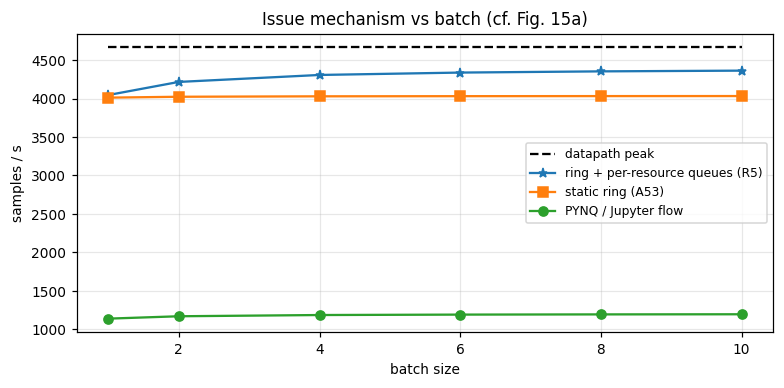

 batch      PYNQ  static ring     tuned      peak  tuned/peak
     1      1139         4011      4046      4664        87%
     2      1169         4023      4216      4664        90%
     4      1185         4029      4306      4664        92%
     6      1191         4030      4337      4664        93%
     8      1194         4031      4353      4664        93%
    10      1195         4032      4362      4664        94%


In [16]:
rows = mc.batch_sweep()
fig, ax = plt.subplots()
bx = [r['batch'] for r in rows]
ax.plot(bx, [r['peak'] for r in rows], 'k--', label='datapath peak')
ax.plot(bx, [r['tuned'] for r in rows], '*-', label='ring + per-resource queues (R5)')
ax.plot(bx, [r['static'] for r in rows], 's-', label='static ring (A53)')
ax.plot(bx, [r['pynq'] for r in rows], 'o-', label='PYNQ / Jupyter flow')
ax.set_xlabel('batch size'); ax.set_ylabel('samples / s')
ax.set_title('Issue mechanism vs batch (cf. Fig. 15a)'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

print(f"{'batch':>6} {'PYNQ':>9} {'static ring':>12} {'tuned':>9} {'peak':>9} {'tuned/peak':>11}")
for r in rows:
    print(f"{r['batch']:>6} {r['pynq']:>9.0f} {r['static']:>12.0f} {r['tuned']:>9.0f} "
          f"{r['peak']:>9.0f} {r['tuned']/r['peak']:>10.0%}")

### What the model says

* **Prefetch saturates at 4–8 descriptors.** Deeper buys nothing at batch 1.
* **Per-resource queues matter only across inferences.** With one shared ring the next sample's input-DMA descriptor sits behind ~100 compute descriptors and cannot be fetched early; splitting the ring takes batch-10 throughput from 4,032 to 4,362 samples/s — **94% of datapath peak**. A cheap change, invisible in a bandwidth analysis.
* **The link is never the constraint**: 0.62 GB/s of 6.4 available, so **one HP port suffices**. The four ports buy burst overlap for a single record, not throughput.
* **The sequencer is ~3.6k LUT, +2.4%** on the Table 11 system — against the 15k already spent on top-level control.
* The residual ~9% at batch 1 is the 128 kB input transfer, which overlaps nothing unless the accelerator ingests from a live AXI-stream SDR front end — an option Fig. 12 already shows, and the strongest single change for a batch-1 claim.

### Practical notes

* Use the **Cortex-R5F in the RPU** to drive the ring: on-die, 500–600 MHz, TCM, deterministic low-latency PL access via `M_AXI_HPM0_LPD`, leaving the A53 for Linux/PYNQ. Split with OpenAMP/rpmsg.
* `pynq.allocate()` gives uncached buffers — right for bulk IQ over HP, wrong for descriptors and completion words, which want cacheable memory through HPC/ACP with explicit flush/invalidate.
* **Do not use PL–PS interrupts for 214 µs jobs**: Linux IRQ latency is 5–10 µs. Write a completion word through ACP and poll it.
* Context switching with an architectural scratchpad is the known hard part (Hwacha and Gemmini both wrestled with it). For an edge RFML box, marking the region process-private and non-preemptible for a command's duration is probably enough — but say so explicitly rather than leaving it implied.

---
# Part IV — Assumptions, and what to measure next

## 4.1 Measured vs assumed

**Measured** (executed code, exact by construction): every cycle of the schedule —
bank conflicts, coverage, PRS/FCS equivalence, arithmetic; FFT/BL results against
`numpy.fft`; Algorithm 3's permutation, conflict freedom and $N/P$ cycle count;
descriptor encoding and program structure.

**Assumed** (all in `MicrocodeConfig`, one line to change):

| assumption | value | confidence |
|---|---|---|
| posted MMIO write | 0.40 µs | medium |
| descriptor fetch over HPC0 | 0.15 µs | medium |
| PYNQ per-transfer cost | 25 µs | soft — but the conclusion holds for 5–50 µs |
| Linux IRQ latency (mmio preset) | 6 µs | medium |
| ACP completion poll | 0.20 µs | medium |
| DDR sustained bandwidth | 6.4 GB/s | conservative; irrelevant at 10% utilisation |
| sequencer LUT | 3k + 40/slot | rough — but 10× off still rounds to "negligible" |

One modelling choice to flag in any write-up: the program adds
`bs.pow`/`bs.mag`/`bs.pool` as separate commands (~16 µs, +7% over 214 µs) which
the RTL may fuse into the surrounding dataflow. If so the real overheads are
slightly lower than shown.

## 4.2 The experiment that would settle it

Build the sequencer on the same ZCU104, reusing the existing Verilog BE array
untouched, and measure three points: the hardwired design (Table 11), the
descriptor ring, and the current PYNQ flow. Two results make it publishable:

1. **programmability costs <10%** at this granularity — the layer graph becomes
   runtime data at essentially no hardware cost;
2. **most of the Fig. 15a solid-vs-dashed gap is PS-side**, which strengthens the
   existing single-batch claim without any PL change.

Adding a streamed AXI input path would close most of the remaining batch-1
residual.

## 4.3 Recommended paper actions

1. **Fix Algorithm 1 lines 5–6** (Part II); `docs/algorithm1_fixed.tex` is drop-in. Also state the whole vector $I^i$, not just $I^i[0]$.
2. **Clarify Eq. (10)**: $P_N$ = number of length-$l$ sequences, $N$ = engine computational length.
3. **State the row-rotation reading of Eq. (3)** — it makes the conflict-freedom argument two lines.
4. Consider noting that the Fig. 15a gap is partly PS-side, with the descriptor-ring number as evidence.

---
# Appendix — source reference

## `flexbe.py`

| symbol | role |
|---|---|
| `popcount`, `bit_rev`, `bit_rev_array`, `insert_zero` | bit primitives |
| `bsm`, `bsm_array` | Eq. (3) bank index |
| `FixedPointFormat` | Q1.15, 32-bit accumulate, convergent rounding, saturation |
| `BankedMemory` | $P$ single-port banks; raises `BankConflictError` |
| `PermuteRotateSwitch`, `fcs_matrix`, `interconnect_cost` | Sec. 3.1 and the Fig. 9 model |
| `CycleControl`, **`algorithm1`**, `ButterflySchedule` | the repaired listing and the full control sequence; `validate()` |
| `fft_coefficients`, `random_bl_coefficients`, `expand_coefficients`, `coefficients_from_paper_layout` | twiddles, BL weights, $P_{sub}$ expansion, Table 4 layout |
| `butterfly_reference` | golden datapath |
| `bitrev_schedule` | Algorithm 3 |
| `FlexBE`, `BEArray` | the engine and the array |
| `cycles_eq10`, `layer_cycles`, `bitrev_cycles` | Eq. (10) |

## `bspnet.py`

`BSPNetConfig` (Table 7) · `CONFIGS` cfg-1..8 · `HWConfig`/`HW` (BE-base-1,
BE-base-2, FlexBE, BSP-Flex with Table 10 $F_{max}$) · `cycle_breakdown`,
`total_cycles`, `latency_ms`, `throughput_sps` · `BSPNet.features` (Eq. 1),
`.branch`, `.forward` · `design_space_table`.

## `microcode.py`

`OPCODES`/`MODES`/`FLAGS` · `Descriptor` (32 B, `encode`/`decode`) · `Command` ·
`build_program` · `MicrocodeConfig`/`PLATFORMS` (pynq, mmio, ring, static, tuned) ·
`Sequencer` → `RunReport` · `compare_platforms`, `ring_depth_sweep`,
`batch_sweep`, `port_budget`, `sequencer_area`.

## `docs/`

`algorithm1_fix.md` — the diagnosis, repair and proof.
`algorithm1_fixed.tex` — drop-in `algorithm2e` listing.

In [17]:
r = subprocess.run([sys.executable, '-m', 'unittest', 'test_flexbe', '-v'],
                   capture_output=True, text=True)
lines = [l for l in r.stderr.splitlines()
         if ' ... ' in l or l.startswith('Ran ') or l.strip() in ('OK','FAILED')]
groups = {}
for l in lines:
    if ' ... ' in l and '(' in l:
        parts = l.split('(')[1].split('.')
        cls = parts[1] if len(parts) > 1 else parts[0].rstrip(')')
        groups.setdefault(cls, []).append(l.split(' ')[0])
for cls, tests in groups.items():
    print(f"{cls} ({len(tests)})")
    for t in tests: print(f"    {t}")
print()
print("\n".join(l for l in lines if l.startswith('Ran ') or l.strip() in ('OK','FAILED')))

TestAlgorithm1 (4)
    test_conflict_free_and_complete
    test_out_of_range_is_rejected
    test_schedule_validates
    test_subset_switch_uses_at_most_m_states
I[0]); S = n-k-1 on  (1)
    R
TestBSPNet (5)
    test_cfg6_latency
    test_feature_extraction_matches_numpy
    test_fft_layer_is_the_headline_number
    test_flexbe_beats_be_base_everywhere
    test_forward_is_deterministic
TestBitHelpers (4)
    test_bit_rev
    test_bsm_scalar_matches_vector
    test_insert_zero
    test_shift_down_is_a_bijection
  (1)
    A
TestBitReversal (3)
    test_algorithm3_is_a_conflict_free_permutation
    test_cycle_count
    test_eq7_destination_bank_law
TestFixedPoint (2)
    test_fxp16_fft_accuracy
    test_quantiser
TestMicrocode (13)
    test_batch_amortises_towards_peak
    test_descriptor_round_trip
    test_double_buffering_matters
    test_every_opcode_encodes
    test_latency_never_beats_the_datapath
    test_link_is_not_the_constraint
    test_per_resource_queues_help_across_inference

---
## How to run

```bash
python test_flexbe.py              # 50 tests, ~3 s
python build_notebook.py           # regenerate this notebook
```

Pure NumPy; matplotlib only for the figures here.